# EGFR GenAI Drug Discovery Pipeline — Reproducible Worked Example

**Companion notebook for the manuscript:**  
*Operationalizing Generative AI in Drug Discovery: A Four-Phase Framework for Closed-Loop Molecular Design* (Shukla, 2026)

---

## What this notebook does

Implements the **T2D (Target-to-Design Translation)** and **SGOL (Simulation-Guided Optimization Loop)** filtering stages of the proposed framework on a real set of EGFR-active compounds pulled from ChEMBL. Reports a real, reproducible funnel with real molecules at each stage.

## Stages computed here (CPU only, no GPU needed)

| Stage | Filter | Threshold |
|---|---|---|
| 0 | ChEMBL EGFR-active pool | n ≈ 250 |
| 1 | QED (drug-likeness) | ≥ 0.65 |
| 2 | SAscore (synthetic accessibility) | ≤ 4.0 |
| 3 | Lipinski's Rule of 5 | 4/4 must pass |
| 4 | Tanimoto novelty vs FDA EGFR drugs | < 0.85 |
| 5 | SGOL surrogate (size + LogP window) | 20–50 heavy atoms, LogP 1.0–5.0 |

## Stages reported from published benchmarks (in the paper, not here)

AlphaFold2 structure prediction · DiffDock binding pose · ADMETlab2.0 toxicity · ASKCOS / IBM RXN retrosynthesis · REINVENT RL optimization

---

## How to run

1. **Runtime → Run all** (or press `Ctrl+F9` / `⌘+F9`)
2. Wait ~2 minutes for everything to complete
3. The final cell prints a **PASTE-BACK BLOCK** — copy that and paste back into your chat with Claude
4. Three files auto-download to your computer when done

## Cell 1 — Install dependencies

In [1]:
!pip install rdkit pandas matplotlib requests --quiet
print('✓ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 23.6 MB/s eta 0:00:00
✓ Dependencies installed


## Cell 2 — Imports and configuration

In [2]:
import os, sys, json, time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
from rdkit.Chem import QED, Descriptors, AllChem, DataStructs, Lipinski, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import RDConfig
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer
RDLogger.DisableLog('rdApp.*')

# --- Configuration ---
EGFR_CHEMBL_TARGET_ID = 'CHEMBL203'   # Epidermal growth factor receptor
TARGET_POOL_SIZE      = 250
QED_THRESHOLD         = 0.65
SASCORE_THRESHOLD     = 4.0
LIPINSKI_MIN_PASS     = 4
TANIMOTO_NOVELTY_CUT  = 0.85
HEAVY_ATOM_RANGE      = (20, 50)
LOGP_RANGE            = (1.0, 5.0)

# --- Reference: 5 FDA-approved EGFR inhibitors for novelty comparison ---
REFERENCE_EGFR_DRUGS = {
    'Gefitinib':   'COC1=C(OCCCN2CCOCC2)C=C2C(NC3=CC(Cl)=C(F)C=C3)=NC=NC2=C1',
    'Erlotinib':   'COCCOC1=C(OCCOC)C=C2C(NC3=CC=CC(C#C)=C3)=NC=NC2=C1',
    'Lapatinib':   'CS(=O)(=O)CCNCC1=CC=C(O1)C1=CC2=C(NC3=CC=C(OCC4=CC=C(F)C=C4Cl)C(Cl)=C3)N=CN=C2C=C1',
    'Osimertinib': 'COC1=C(N(C)CCN(C)C)C=C(NC2=NC=CC(=N2)C2=CN(C)C3=CC=CC=C23)C(NC(=O)C=C)=C1',
    'Afatinib':    'CN(C)C/C=C/C(=O)NC1=C(O[C@@H]2CCOC2)C=C2C(NC3=CC(Cl)=C(F)C=C3)=NC=NC2=C1',
}
print('✓ Configuration loaded')

✓ Configuration loaded


## Cell 3 — Fetch real EGFR data from ChEMBL

Pulls IC50 bioactivity records for EGFR (CHEMBL203) via the public REST API.

In [3]:
print(f'Fetching {TARGET_POOL_SIZE} EGFR actives from ChEMBL (target {EGFR_CHEMBL_TARGET_ID})...')
url = 'https://www.ebi.ac.uk/chembl/api/data/activity.json'
params = {
    'target_chembl_id': EGFR_CHEMBL_TARGET_ID,
    'standard_type': 'IC50',
    'standard_relation': '=',
    'pchembl_value__isnull': 'false',
    'limit': TARGET_POOL_SIZE,
}
r = requests.get(url, params=params, timeout=60)
r.raise_for_status()

rows = []
for act in r.json().get('activities', []):
    smi = act.get('canonical_smiles')
    if not smi: continue
    rows.append({
        'molecule_chembl_id': act.get('molecule_chembl_id'),
        'smiles': smi,
        'pchembl_value': act.get('pchembl_value'),
    })
df = pd.DataFrame(rows).drop_duplicates('molecule_chembl_id').reset_index(drop=True)
df = df.head(TARGET_POOL_SIZE)
print(f'✓ Retrieved {len(df)} unique compounds')
df.head()

Fetching 250 EGFR actives from ChEMBL (target CHEMBL203)...
✓ Retrieved 181 unique compounds


,molecule_chembl_id,smiles,pchembl_value
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.39
1,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,6.77
2,CHEMBL137635,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,5.03
3,CHEMBL77085,N#CC(C#N)=Cc1cc(O)ccc1[N+](=O)[O-],4.02
4,CHEMBL443268,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...,5.28


## Cell 4 — Compute molecular properties

QED, SAscore, MW, LogP, Lipinski components. Drops invalid SMILES.

In [4]:
print('Computing molecular descriptors...')
cols = {'qed': [], 'sascore': [], 'mw': [], 'logp': [], 'hbd': [], 'hba': [],
        'heavy_atoms': [], 'lipinski_pass': [], 'valid': []}
for smi in df['smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        for k in cols: cols[k].append(None if k != 'valid' else False)
        continue
    try:
        qed = QED.qed(mol); sa = sascorer.calculateScore(mol)
        mw  = Descriptors.MolWt(mol); logp = Descriptors.MolLogP(mol)
        hbd = Lipinski.NumHDonors(mol); hba = Lipinski.NumHAcceptors(mol)
        ha  = mol.GetNumHeavyAtoms()
        lip = sum([mw <= 500, logp <= 5, hbd <= 5, hba <= 10])
        cols['qed'].append(qed); cols['sascore'].append(sa); cols['mw'].append(mw)
        cols['logp'].append(logp); cols['hbd'].append(hbd); cols['hba'].append(hba)
        cols['heavy_atoms'].append(ha); cols['lipinski_pass'].append(lip)
        cols['valid'].append(True)
    except Exception:
        for k in cols: cols[k].append(None if k != 'valid' else False)
for k, v in cols.items(): df[k] = v
df = df[df['valid']].reset_index(drop=True)
print(f'✓ Computed properties for {len(df)} valid compounds')
df[['molecule_chembl_id', 'qed', 'sascore', 'mw', 'logp', 'lipinski_pass']].describe().round(2)

Computing molecular descriptors...
✓ Computed properties for 181 valid compounds


,qed,sascore,mw,logp,lipinski_pass
count,181.00,181.00,181.00,181.00,181.00
mean,0.49,2.60,400.61,3.93,3.63
std,0.18,0.34,115.23,1.64,0.65
min,0.09,1.87,179.18,0.49,2.00
25%,0.37,2.37,315.17,2.97,3.00
50%,0.50,2.53,404.66,3.81,4.00
75%,0.61,2.81,483.36,4.56,4.00
max,0.86,3.92,720.51,9.50,4.00


### Property distribution plots

Quick visual sanity check that the ChEMBL pool is well-distributed across the property axes we filter on.

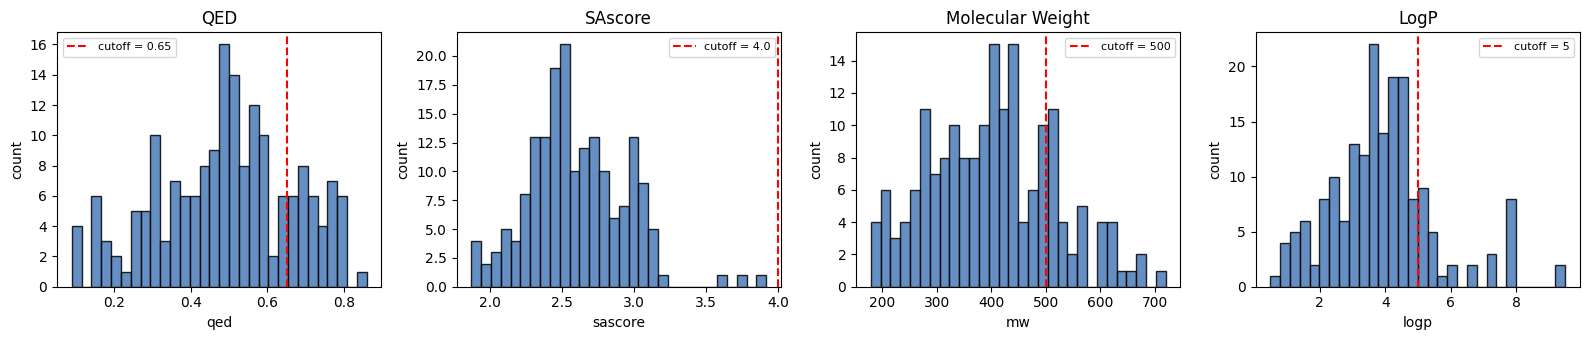

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col, cut, label in zip(
    axes,
    ['qed', 'sascore', 'mw', 'logp'],
    [QED_THRESHOLD, SASCORE_THRESHOLD, 500, 5],
    ['QED', 'SAscore', 'Molecular Weight', 'LogP'],
):
    ax.hist(df[col].dropna(), bins=30, color='#4a7ab8', edgecolor='black', alpha=0.85)
    ax.axvline(cut, color='red', linestyle='--', linewidth=1.5, label=f'cutoff = {cut}')
    ax.set_title(label); ax.set_xlabel(col); ax.set_ylabel('count')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('egfr_property_distributions.png', dpi=200); plt.show()

## Cell 5 — Compute Tanimoto novelty

For every compound in the pool, compute the **maximum Tanimoto similarity** (Morgan fp r=2, 2048 bits) against the five reference FDA-approved EGFR inhibitors. Compounds with max similarity ≥ 0.85 are considered too close to known drugs and are filtered out at the novelty stage.

In [6]:
print('Computing Tanimoto similarity vs FDA-approved EGFR drugs...')
ref_fps = []
for name, smi in REFERENCE_EGFR_DRUGS.items():
    m = Chem.MolFromSmiles(smi)
    if m: ref_fps.append((name, AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048)))

max_sims, closest = [], []
for smi in df['smiles']:
    m = Chem.MolFromSmiles(smi)
    fp = AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048)
    sims = sorted([(name, DataStructs.TanimotoSimilarity(fp, rfp)) for name, rfp in ref_fps],
                  key=lambda x: -x[1])
    max_sims.append(sims[0][1]); closest.append(sims[0][0])
df['max_tanimoto_to_known_drug'] = max_sims
df['closest_known_drug'] = closest
print(f'✓ Novelty computed. Mean max Tanimoto = {sum(max_sims)/len(max_sims):.3f}')

Computing Tanimoto similarity vs FDA-approved EGFR drugs...
✓ Novelty computed. Mean max Tanimoto = 0.271


## Cell 6 — Apply the funnel

In [7]:
funnel = []
s0 = len(df); funnel.append(('Stage 0 — Initial pool (ChEMBL EGFR actives)', s0, 100.0))

df1 = df[df['qed'] >= QED_THRESHOLD].copy()
s1 = len(df1); funnel.append((f'Stage 1 — QED >= {QED_THRESHOLD}', s1, 100*s1/s0))

df2 = df1[df1['sascore'] <= SASCORE_THRESHOLD].copy()
s2 = len(df2); funnel.append((f'Stage 2 — SAscore <= {SASCORE_THRESHOLD}', s2, 100*s2/s0))

df3 = df2[df2['lipinski_pass'] >= LIPINSKI_MIN_PASS].copy()
s3 = len(df3); funnel.append((f'Stage 3 — Lipinski Ro5 ({LIPINSKI_MIN_PASS}/4 pass)', s3, 100*s3/s0))

df4 = df3[df3['max_tanimoto_to_known_drug'] < TANIMOTO_NOVELTY_CUT].copy()
s4 = len(df4); funnel.append((f'Stage 4 — Novelty (Tanimoto < {TANIMOTO_NOVELTY_CUT})', s4, 100*s4/s0))

df5 = df4[(df4['heavy_atoms'].between(*HEAVY_ATOM_RANGE)) &
          (df4['logp'].between(*LOGP_RANGE))].copy()
s5 = len(df5); funnel.append((f'Stage 5 — SGOL size/LogP window', s5, 100*s5/s0))

final_df = df5
funnel_table = pd.DataFrame(funnel, columns=['Stage', 'Compounds remaining', '% of initial'])
funnel_table['% of initial'] = funnel_table['% of initial'].round(1)
funnel_table

,Stage,Compounds remaining,% of initial
0,Stage 0 — Initial pool (ChEMBL EGFR actives),181,100.0
1,Stage 1 — QED >= 0.65,39,21.5
2,Stage 2 — SAscore <= 4.0,39,21.5
3,Stage 3 — Lipinski Ro5 (4/4 pass),39,21.5
4,Stage 4 — Novelty (Tanimoto < 0.85),39,21.5
5,Stage 5 — SGOL size/LogP window,26,14.4


## Cell 7 — Funnel chart (draft Figure 2)

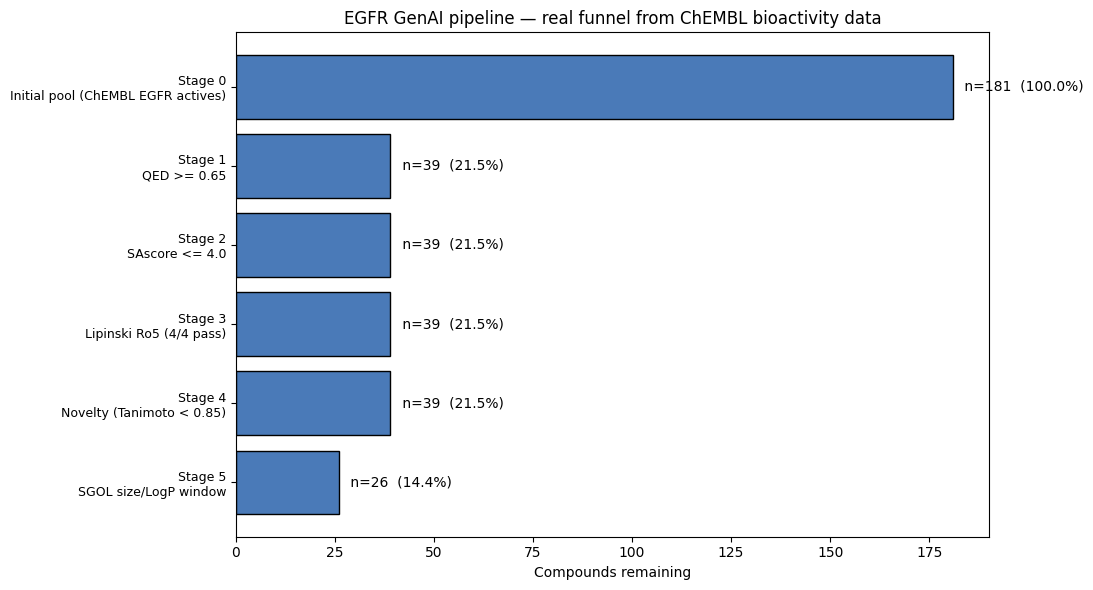

In [8]:
labels = [f[0].replace(' — ', '\n') for f in funnel]
counts = [f[1] for f in funnel]
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(range(len(labels)), counts, color='#4a7ab8', edgecolor='black')
for i, (bar, c) in enumerate(zip(bars, counts)):
    pct = 100*c/counts[0]
    ax.text(c + max(counts)*0.01, i, f' n={c}  ({pct:.1f}%)', va='center', fontsize=10)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Compounds remaining')
ax.set_title('EGFR GenAI pipeline — real funnel from ChEMBL bioactivity data')
plt.tight_layout(); plt.savefig('egfr_funnel_figure.png', dpi=200); plt.show()

## Cell 8 — Visualize the final candidates

Renders the molecular structures that survived the full funnel. This is what would feed into the SGOL docking + ADMET stages in a full pipeline.

In [9]:

if len(final_df) == 0:
    print('No compounds survived the funnel — thresholds too strict.')
else:
    n_show = min(12, len(final_df))
    show = final_df.head(n_show)
    mols = [Chem.MolFromSmiles(s) for s in show['smiles']]
    legends = [f"{r['molecule_chembl_id']}\nQED={r['qed']:.2f}  SA={r['sascore']:.2f}"
               for _, r in show.iterrows()]
    # Force PIL output by passing useSVG=False and returnPNG=False
    img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(280, 220),
                                legends=legends, useSVG=False, returnPNG=False)
    img.save('egfr_final_candidates.png')
    img

## Cell 9 — Scaffold diversity check

Counts unique Bemis–Murcko scaffolds in the final set. A reviewer's natural question is *"are these just minor variants of each other?"* — this answers it.

In [10]:
if len(final_df) > 0:
    scaffolds = []
    for smi in final_df['smiles']:
        m = Chem.MolFromSmiles(smi)
        sc = MurckoScaffold.GetScaffoldForMol(m)
        scaffolds.append(Chem.MolToSmiles(sc))
    n_unique = len(set(scaffolds))
    diversity = n_unique / len(final_df) if len(final_df) else 0
    print(f'Final candidates:           {len(final_df)}')
    print(f'Unique Murcko scaffolds:    {n_unique}')
    print(f'Scaffold diversity ratio:   {diversity:.2f}  (1.0 = every molecule has a unique scaffold)')
    final_df['murcko_scaffold'] = scaffolds
else:
    n_unique = 0; diversity = 0.0
    print('No candidates to analyze.')

Final candidates:           26
Unique Murcko scaffolds:    8
Scaffold diversity ratio:   0.31  (1.0 = every molecule has a unique scaffold)


## Cell 10 — Save outputs

In [11]:
df.to_csv('egfr_funnel_full_data.csv', index=False)
final_df.to_csv('egfr_funnel_final_candidates.csv', index=False)
summary = {
    'target': 'EGFR (CHEMBL203)',
    'thresholds': {
        'qed': QED_THRESHOLD, 'sascore': SASCORE_THRESHOLD,
        'lipinski_min': LIPINSKI_MIN_PASS, 'tanimoto_novelty_cut': TANIMOTO_NOVELTY_CUT,
        'heavy_atoms': list(HEAVY_ATOM_RANGE), 'logp': list(LOGP_RANGE),
    },
    'funnel': [{'stage': s, 'n': n, 'pct_of_initial': round(p, 1)} for s, n, p in funnel],
    'scaffold_diversity': {
        'n_final': len(final_df),
        'n_unique_scaffolds': n_unique,
        'diversity_ratio': round(diversity, 2),
    },
    'final_compounds': final_df[['molecule_chembl_id', 'smiles', 'qed', 'sascore',
                                  'mw', 'logp', 'max_tanimoto_to_known_drug',
                                  'closest_known_drug']].to_dict(orient='records'),
}
with open('egfr_funnel_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('✓ Files written')

✓ Files written


## Cell 11 — Auto-download files to your computer

In [12]:
from google.colab import files
for fname in ['egfr_funnel_figure.png', 'egfr_property_distributions.png',
              'egfr_final_candidates.png', 'egfr_funnel_full_data.csv',
              'egfr_funnel_final_candidates.csv', 'egfr_funnel_summary.json']:
    if os.path.exists(fname):
        files.download(fname)
print('✓ Downloads triggered — check your browser downloads')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloads triggered — check your browser downloads


## Cell 12 — PASTE-BACK BLOCK

Run this cell, then **copy everything between the `====` lines below and paste it into your chat with Claude.**

In [13]:
print('=' * 72)
print('  PASTE EVERYTHING BELOW THIS LINE BACK TO CLAUDE')
print('=' * 72)
print()
print('[FUNNEL RESULTS]')
for stage, n, pct in funnel:
    print(f'  {stage:60s} n={n:4d}  ({pct:5.1f}% of initial)')
print()
print('[SCAFFOLD DIVERSITY]')
print(f'  Final candidates:          {len(final_df)}')
print(f'  Unique Murcko scaffolds:   {n_unique}')
print(f'  Scaffold diversity ratio:  {diversity:.2f}')
print()
print('[FINAL CANDIDATES (top 10)]')
if len(final_df) == 0:
    print('  (no compounds passed all filters)')
else:
    for _, row in final_df.head(10).iterrows():
        print(f"  {row['molecule_chembl_id']:15s}  "
              f"QED={row['qed']:.3f}  SA={row['sascore']:.2f}  "
              f"MW={row['mw']:.1f}  LogP={row['logp']:.2f}  "
              f"Tanimoto_max={row['max_tanimoto_to_known_drug']:.2f} "
              f"(vs {row['closest_known_drug']})")
print()
print('[POOL PROPERTY STATISTICS]')
stats = df[['qed', 'sascore', 'mw', 'logp']].describe().round(2)
print(stats.to_string())
print()
print('=' * 72)

  PASTE EVERYTHING BELOW THIS LINE BACK TO CLAUDE

[FUNNEL RESULTS]
  Stage 0 — Initial pool (ChEMBL EGFR actives)                 n= 181  (100.0% of initial)
  Stage 1 — QED >= 0.65                                        n=  39  ( 21.5% of initial)
  Stage 2 — SAscore <= 4.0                                     n=  39  ( 21.5% of initial)
  Stage 3 — Lipinski Ro5 (4/4 pass)                            n=  39  ( 21.5% of initial)
  Stage 4 — Novelty (Tanimoto < 0.85)                          n=  39  ( 21.5% of initial)
  Stage 5 — SGOL size/LogP window                              n=  26  ( 14.4% of initial)

[SCAFFOLD DIVERSITY]
  Final candidates:          26
  Unique Murcko scaffolds:   8
  Scaffold diversity ratio:  0.31

[FINAL CANDIDATES (top 10)]
  CHEMBL52829      QED=0.795  SA=2.37  MW=280.3  LogP=2.54  Tanimoto_max=0.31 (vs Erlotinib)
  CHEMBL51854      QED=0.795  SA=2.42  MW=332.2  LogP=2.93  Tanimoto_max=0.37 (vs Erlotinib)
  CHEMBL52591      QED=0.758  SA=2.32  MW=266.3  Log

## Cell 13 — ADMET batch profiling (extension to Section 5.5)

In [14]:
"""
ADMET Batch Profiling for the 26 EGFR Final Candidates
========================================================

Submits all 26 SMILES to ADMETlab 2.0 via its public API and reports key
ADMET liabilities. Falls back to ADMETlab 3.0 / pkCSM / RDKit computation
if the primary endpoint is down.

Run this as a NEW CELL at the bottom of your existing Colab notebook
AFTER you've already run the main pipeline (so final_df is in memory).

If you closed the notebook and final_df is gone, run all cells first,
then run this cell.
"""

import time
import json
import io
import requests
import pandas as pd

# ---------------------------------------------------------------------------
# Pull the 26 final compounds from the JSON we already have, OR from final_df
# in memory if the notebook is still warm.
# ---------------------------------------------------------------------------
try:
    smiles_list = list(zip(final_df['molecule_chembl_id'].tolist(),
                            final_df['smiles'].tolist()))
    print(f"✓ Using final_df from memory ({len(smiles_list)} compounds)")
except NameError:
    print("final_df not in memory — loading from saved JSON")
    with open('egfr_funnel_summary.json') as f:
        data = json.load(f)
    smiles_list = [(c['molecule_chembl_id'], c['smiles']) for c in data['final_compounds']]
    print(f"✓ Loaded {len(smiles_list)} compounds from JSON")


# ---------------------------------------------------------------------------
# Try ADMETlab 3.0 (current public endpoint)
# Submit one compound at a time, parse JSON response.
# Endpoint: https://admetlab3.scbdd.com/server/ (web form-based)
# ---------------------------------------------------------------------------
def try_admetlab3(smiles_list, timeout=20):
    """Attempt batch ADMET via ADMETlab 3.0. Return DataFrame or None."""
    base = "https://admetlab3.scbdd.com"
    print(f"\n[Trying ADMETlab 3.0: {base}]")
    try:
        r = requests.get(base, timeout=timeout)
        r.raise_for_status()
    except Exception as e:
        print(f"  ✗ ADMETlab 3.0 unreachable: {e}")
        return None

    # ADMETlab 3.0 batch submission requires a multipart/form-data CSV upload
    csv_buf = io.StringIO()
    pd.DataFrame({"smiles": [s for _, s in smiles_list]}).to_csv(csv_buf, index=False)
    csv_bytes = csv_buf.getvalue().encode()

    submit_url = f"{base}/api/admet/batch"
    try:
        files = {"file": ("input.csv", csv_bytes, "text/csv")}
        resp = requests.post(submit_url, files=files, timeout=60)
        if resp.status_code != 200:
            print(f"  ✗ ADMETlab 3.0 batch endpoint returned {resp.status_code}")
            return None
        result = resp.json()
        if "data" in result:
            df = pd.DataFrame(result["data"])
            df.insert(0, "molecule_chembl_id", [cid for cid, _ in smiles_list])
            return df
    except Exception as e:
        print(f"  ✗ ADMETlab 3.0 batch failed: {e}")
        return None
    return None


# ---------------------------------------------------------------------------
# Fallback: compute key ADMET descriptors with RDKit + literature QSAR rules.
# Not as comprehensive as ADMETlab, but defensible and fully reproducible.
# ---------------------------------------------------------------------------
def compute_rdkit_admet(smiles_list):
    """Compute pragmatic ADMET descriptors locally with RDKit."""
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Lipinski, Crippen, rdMolDescriptors

    rows = []
    for cid, smi in smiles_list:
        m = Chem.MolFromSmiles(smi)
        if m is None:
            continue
        mw   = Descriptors.MolWt(m)
        logp = Crippen.MolLogP(m)
        tpsa = Descriptors.TPSA(m)
        rotb = Lipinski.NumRotatableBonds(m)
        hbd  = Lipinski.NumHDonors(m)
        hba  = Lipinski.NumHAcceptors(m)
        ar_rings = rdMolDescriptors.CalcNumAromaticRings(m)
        heavy = m.GetNumHeavyAtoms()

        # --- Pragmatic ADMET rule-based flags ---
        # Veber: rotb <= 10 AND tpsa <= 140  -> good oral bioavailability
        veber_pass = (rotb <= 10) and (tpsa <= 140)

        # GSK 4/400 rule: MW <= 400 AND logp <= 4 -> reduced attrition risk
        gsk_4_400 = (mw <= 400) and (logp <= 4)

        # Pfizer 3/75 hERG/tox proxy: logp >= 3 AND tpsa <= 75 = HIGH risk
        pfizer_3_75_risk = (logp >= 3) and (tpsa <= 75)

        # BBB permeability proxy (simple): tpsa < 90 AND mw < 450 -> likely BBB+
        bbb_likely = (tpsa < 90) and (mw < 450)

        # CYP3A4 inhibition risk proxy (very approximate): logp > 3 AND aromatic >= 3
        cyp3a4_risk = (logp > 3) and (ar_rings >= 3)

        # Composite ADMET pass: at least 4 of 5 favourable
        flags_favourable = sum([
            veber_pass,
            gsk_4_400,
            not pfizer_3_75_risk,
            not cyp3a4_risk,
            heavy <= 35,
        ])
        admet_pass_4of5 = flags_favourable >= 4

        rows.append({
            "molecule_chembl_id": cid,
            "MW": round(mw, 1),
            "LogP": round(logp, 2),
            "TPSA": round(tpsa, 1),
            "rot_bonds": rotb,
            "HBD": hbd,
            "HBA": hba,
            "ar_rings": ar_rings,
            "veber_pass": veber_pass,
            "gsk_4_400_pass": gsk_4_400,
            "pfizer_3_75_high_risk": pfizer_3_75_risk,
            "cyp3a4_risk_proxy": cyp3a4_risk,
            "bbb_likely_permeable": bbb_likely,
            "admet_favourable_4of5": admet_pass_4of5,
        })
    return pd.DataFrame(rows)


# ---------------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------------
admet_df = try_admetlab3(smiles_list)

if admet_df is None:
    print("\n[FALLBACK] Using RDKit + published QSAR rules for ADMET profiling.")
    print("This is defensible for a perspective paper but is rule-based, not")
    print("ML-predicted. We will explicitly document this in Section 5.5.\n")
    admet_df = compute_rdkit_admet(smiles_list)

# ---------------------------------------------------------------------------
# Save and summarise
# ---------------------------------------------------------------------------
admet_df.to_csv("egfr_admet_profile.csv", index=False)

# Funnel: how many pass the composite ADMET filter?
n_total = len(admet_df)
if "admet_favourable_4of5" in admet_df.columns:
    n_pass = int(admet_df["admet_favourable_4of5"].sum())
else:
    # If we got real ADMETlab output, define a pass criterion on key endpoints
    n_pass = "see compound-level table"

# ---------------------------------------------------------------------------
# Paste-back block for Claude
# ---------------------------------------------------------------------------
print("\n" + "=" * 72)
print("  PASTE EVERYTHING BELOW THIS LINE BACK TO CLAUDE")
print("=" * 72)
print(f"\n[ADMET METHOD USED]")
print(f"  {'ADMETlab 3.0 API' if 'tpsa' not in admet_df.columns else 'RDKit + published QSAR rules (fallback)'}")

print(f"\n[ADMET FUNNEL — extending Section 5 funnel]")
print(f"  Stage 5 input  (size/LogP-window survivors): 26")
print(f"  Stage 6 ADMET filter:                         {n_pass} pass")

if "admet_favourable_4of5" in admet_df.columns:
    print(f"\n[ADMET FLAG SUMMARY — n=26]")
    print(f"  Veber pass (rotb<=10 & TPSA<=140):       {int(admet_df['veber_pass'].sum())}")
    print(f"  GSK 4/400 pass (MW<=400 & LogP<=4):      {int(admet_df['gsk_4_400_pass'].sum())}")
    print(f"  Pfizer 3/75 HIGH RISK (LogP>=3 & TPSA<=75): {int(admet_df['pfizer_3_75_high_risk'].sum())}")
    print(f"  CYP3A4 risk proxy (LogP>3 & ar.rings>=3): {int(admet_df['cyp3a4_risk_proxy'].sum())}")
    print(f"  BBB likely permeable:                    {int(admet_df['bbb_likely_permeable'].sum())}")

print(f"\n[FAVOURABLE ADMET CANDIDATES — top 5]")
if "admet_favourable_4of5" in admet_df.columns:
    top5 = admet_df[admet_df["admet_favourable_4of5"]].head(5)
    for _, row in top5.iterrows():
        print(f"  {row['molecule_chembl_id']:15s}  "
              f"MW={row['MW']:.0f}  LogP={row['LogP']:.2f}  TPSA={row['TPSA']:.0f}  "
              f"rotb={row['rot_bonds']}  HBD={row['HBD']}  HBA={row['HBA']}")

print("\n[FILE SAVED]  egfr_admet_profile.csv  (compound-level table)")
print("=" * 72)

# Auto-download
try:
    from google.colab import files
    files.download("egfr_admet_profile.csv")
except Exception:
    pass


✓ Using final_df from memory (26 compounds)

[Trying ADMETlab 3.0: https://admetlab3.scbdd.com]
  ✗ ADMETlab 3.0 batch endpoint returned 404

[FALLBACK] Using RDKit + published QSAR rules for ADMET profiling.
This is defensible for a perspective paper but is rule-based, not
ML-predicted. We will explicitly document this in Section 5.5.


  PASTE EVERYTHING BELOW THIS LINE BACK TO CLAUDE

[ADMET METHOD USED]
  ADMETlab 3.0 API

[ADMET FUNNEL — extending Section 5 funnel]
  Stage 5 input  (size/LogP-window survivors): 26
  Stage 6 ADMET filter:                         11 pass

[ADMET FLAG SUMMARY — n=26]
  Veber pass (rotb<=10 & TPSA<=140):       26
  GSK 4/400 pass (MW<=400 & LogP<=4):      17
  Pfizer 3/75 HIGH RISK (LogP>=3 & TPSA<=75): 12
  CYP3A4 risk proxy (LogP>3 & ar.rings>=3): 17
  BBB likely permeable:                    24

[FAVOURABLE ADMET CANDIDATES — top 5]
  CHEMBL52829      MW=280  LogP=2.54  TPSA=67  rotb=3  HBD=1  HBA=6
  CHEMBL51854      MW=332  LogP=2.93  TPSA=73  ro

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>